<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Density-Based%20Clustering" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET INFORMATION
Dataset Shape: (200, 6)

First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']

MISSING VALUES
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
dtype: int64

DBSCAN CLUSTERING RESULTS

Cluster Labels:
Cluster
-1      6
 0    194
Name: count, dtype: int64

Noise Points: 6
Silho

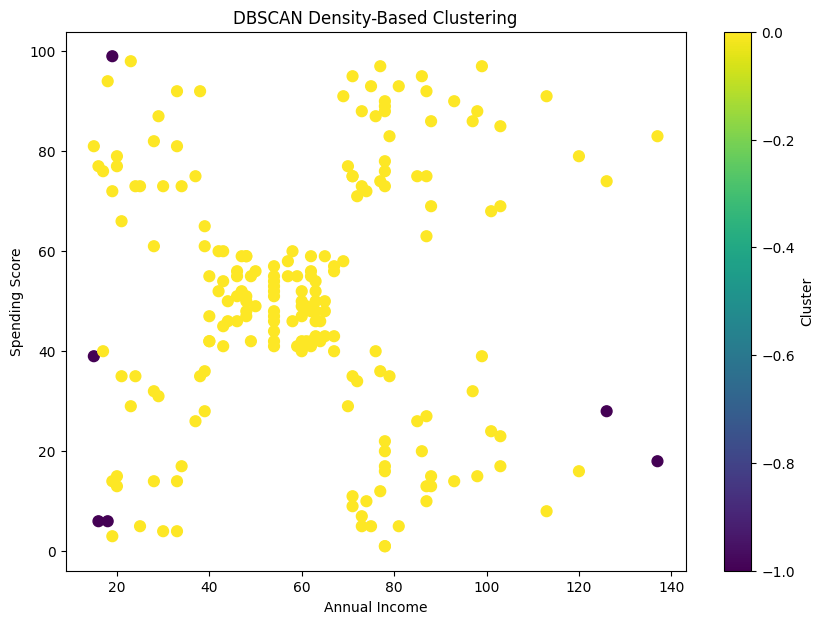

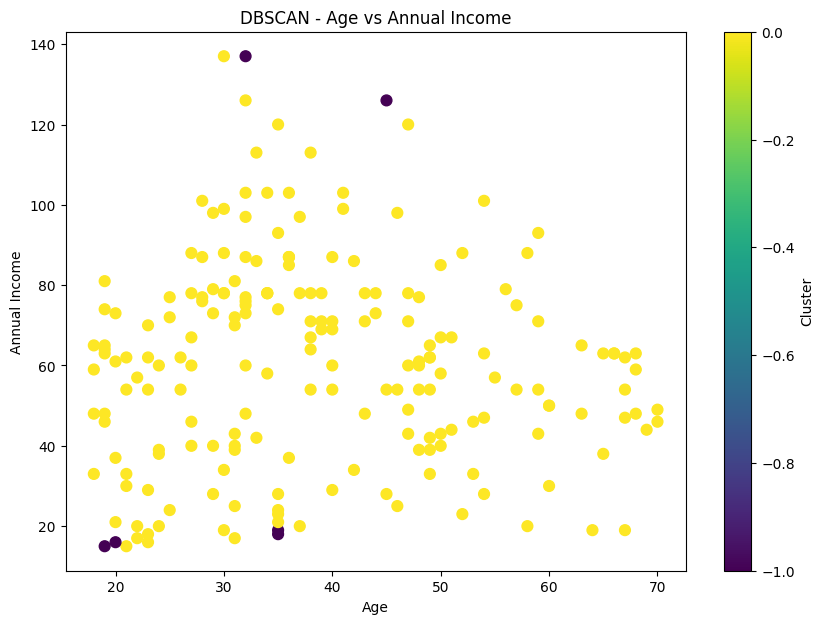


RESULT SAVED
dbscan_clustered_customers.csv created successfully.


In [12]:
# ============================================================
# DENSITY-BASED CLUSTERING - DBSCAN
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


# ============================================================
# 1. LOAD DATASET (Using existing DataFrame)
# ============================================================

# df = pd.read_csv(
#     "/content/Mall_Customers.csv"
# )

# Assuming df is already loaded from previous steps
# If df is not loaded, uncomment the line above and ensure the file path is correct

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())


# ============================================================
# 3. SELECT FEATURES
# ============================================================

features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]


# ============================================================
# 4. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ============================================================
# 5. CREATE DBSCAN MODEL
# ============================================================

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)


# ============================================================
# 6. FIT MODEL
# ============================================================

clusters = dbscan.fit_predict(
    X_scaled
)


# ============================================================
# 7. ADD CLUSTER TO DATASET
# ============================================================

df["Cluster"] = clusters


# ============================================================
# 8. DISPLAY CLUSTER RESULTS
# ============================================================

print("\n" + "=" * 70)
print("DBSCAN CLUSTERING RESULTS")
print("=" * 70)

print("\nCluster Labels:")
print(
    df["Cluster"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 9. COUNT NOISE POINTS
# ============================================================

noise_count = sum(
    df["Cluster"] == -1
)

print("\nNoise Points:", noise_count)


# ============================================================
# 10. SILHOUETTE SCORE
# ============================================================

# Remove noise points for silhouette calculation
mask = df["Cluster"] != -1

X_clustered = X_scaled[mask]

labels_clustered = df.loc[
    mask,
    "Cluster"
]

# Silhouette score requires at least 2 clusters
if len(set(labels_clustered)) >= 2:

    silhouette = silhouette_score(
        X_clustered,
        labels_clustered
    )

    print(
        "Silhouette Score:",
        round(silhouette, 4)
    )

else:

    print(
        "Silhouette Score: Cannot be calculated"
    )


# ============================================================
# 11. CLUSTER SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CLUSTER SUMMARY")
print("=" * 70)

summary = df.groupby(
    "Cluster"
)[features].mean()

print(summary)


# ============================================================
# 12. DBSCAN GRAPH
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.xlabel(
    "Annual Income"
)

plt.ylabel(
    "Spending Score"
)

plt.title(
    "DBSCAN Density-Based Clustering"
)

plt.colorbar(
    label="Cluster"
)

plt.show()


# ============================================================
# 13. AGE VS INCOME GRAPH
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    df["Age"],
    df["Annual Income (k$)"],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.xlabel("Age")

plt.ylabel(
    "Annual Income"
)

plt.title(
    "DBSCAN - Age vs Annual Income"
)

plt.colorbar(
    label="Cluster"
)

plt.show()


# ============================================================
# 14. SAVE RESULTS
# ============================================================

df.to_csv(
    "dbscan_clustered_customers.csv",
    index=False
)

print("\n" + "=" * 70)
print("RESULT SAVED")
print("=" * 70)

print(
    "dbscan_clustered_customers.csv "
    "created successfully."
)